# Text Analytics Coursework

This notebook provides some example code for loading and examining the dataset for task 2.

In [ ]:
# %load_ext autoreload
# %autoreload 2

# Use HuggingFace's datasets library to access the Emotion dataset
from datasets import load_dataset
import numpy as np
import pandas as pd

# Task 2 - EBM-NLP

This dataset is provided at https://github.com/bepnye/EBM-NLP and a copy has been made available in this repository for convenience. The data will need to be unzipped:

In [ ]:
import tarfile
import os

path_tofile = "./ebm_nlp_2_00.tar.gz"
extract_directory = os.path.dirname(path_tofile)

if tarfile.is_tarfile(path_tofile):
    with tarfile.open(path_tofile) as f:
        f.extractall(path=extract_directory)  # Extract all members from the archive to the current working directory


/tmp/ipykernel_1989/767979551.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  f.extractall(path=extract_directory)  # Extract all members from the archive to the current working directory


The data contains text documents that are annotated for mentions of participants, interventions and outcomes (PIO) in medical research. For each entity type, P, I, or O, there is a slightly different set of documents in the training and test set. Most of the documents are identical, but each type has a few extra documents. So, let's deal with each type separately for now.

To load the text documents, we first make a list of the document IDs for one entity type (P, I or O):

In [ ]:
from pathlib import Path

DATA_DIR = Path("./ebm_nlp_2_00")

docs_dir = DATA_DIR / "documents"

def get_doc_ids(split="train", label_type="participants"):
    """
    split: 'train' or 'test'
    """

    if split == "test":
        split = "test/gold"

    train_dir = (
        DATA_DIR
        / "annotations"
        / "aggregated"
        / "hierarchical_labels"
        / label_type  # assuming that the split is the same for all entity types, we can just look at one of them
        / split
    )

    doc_ids = [p.stem.split(".")[0] for p in train_dir.glob("*.AGGREGATED.ann")]
    print(doc_ids)
    return sorted(doc_ids)

doc_ids_p = get_doc_ids("train", "participants")
test_doc_ids_p = get_doc_ids("test", "participants")

print(f"Number of documents in train split for participants: {len(doc_ids_p)}")
print(f"Number of documents in test split for participants: {len(test_doc_ids_p)}")


['8436747', '20603436', '9235679', '17453398', '9342133', '7491394', '16393740', '17089419', '9394942', '10539493', '22740508', '23104617', '25660225', '11536065', '23017624', '7907677', '350565', '15283485', '22079053', '1640362', '23715565', '3825543', '24752311', '22683613', '16882678', '3108794', '19696287', '2915887', '15894964', '17912634', '23605599', '21575074', '11804430', '18339046', '18946011', '17694216', '14685645', '9825232', '22277317', '24920862', '8268649', '14716650', '2975995', '2956874', '20863389', '11100343', '7977921', '25619686', '24824660', '10356632', '2576261', '18205945', '15324531', '6850464', '22617130', '7956382', '20936417', '7761011', '16880243', '11876712', '24626980', '7881024', '1553169', '17901881', '2319047', '24988121', '3063541', '6667628', '15562654', '15746480', '20329618', '3539897', '396086', '11710599', '15055365', '11073017', '18004169', '9819368', '25017958', '8297739', '2939214', '25629971', '21135366', '15606733', '23874533', '19852790',

Now, we can get the annotations for the first entity type:

In [ ]:
def load_labels_for_doc(doc_id, label_type="participants", split="train"):
    """
    label_type: 'participants', 'interventions', or 'outcomes'
    split: 'train' or 'test'
    """
    if split == "test":
        split = "test/gold"

    ann_path = DATA_DIR / "annotations" / "aggregated" / "hierarchical_labels" / label_type / split/ f"{doc_id}.AGGREGATED.ann"

    if not ann_path.exists():
        print(ann_path, "does not exist!")
        return None

    with open(ann_path, "r", encoding="utf-8") as f:
        labels = [line.strip() for line in f]

    return labels

def load_labels(doc_ids, label_type="participants", split="train"):
    labels = []
    for doc_id in doc_ids:
        doc_labels = load_labels_for_doc(doc_id, label_type, split)
        if doc_labels is not None:
            labels.append(doc_labels)
    return labels

participants_labels = load_labels(doc_ids_p, "participants", split="train")

print(f"Length of participants_labels: {len(participants_labels)}")

test_participants_labels = load_labels(test_doc_ids_p, "participants", split="test")
print(f"Length of test_participants_labels: {len(test_participants_labels)}")

sample = 123
print("Document ID:", doc_ids_p[sample])
print(f"Participants label example for doc {doc_ids_p[sample]}:")
print(participants_labels[sample])

Length of participants_labels: 4609
Length of test_participants_labels: 189
Document ID: 10674680
Participants label example for doc 10674680:
['0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '4', '4', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '1', '1', '1', '1', '1', '1', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '3', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '

In [ ]:
from itertools import chain
import numpy as np

all_labels = chain(*participants_labels)

# show how many unique labels there are across the dataset
print(np.unique(list(all_labels)))

['0' '1' '2' '3' '4']


Let's look at what labels there are for Participants. The code above shows there are four values: 0 corresponds to 'outside' but 1-4 all indicate tokens that form an entity span. Each number is a level in a hierarchy of specificity. To start with let's not worry about this 'hierarchy'. We can instead just turn the labels into simple BIO (Beginning of a span, Inside a span, and Outside a span) tags.

In [ ]:
def hierarchical_to_bio(tags):
    """
    Convert EBM-NLP hierarchical labels (0–4) to flat BIO tags.

    Parameters
    ----------
    tags : list[int]
        A list of hierarchical labels for a single document.

    Returns
    -------
    list[str]
        BIO tags ("O", "B", "I").
    """

    bio = []
    prev = 0

    for t in tags:
        t = int(t)  # ensure it's an integer
        if t == 0:
            bio.append("O")
        else:
            if prev == 0:
                bio.append("B")
            else:
                bio.append("I")

        prev = t


    return bio

def convert_all_labels_to_bio(labels):
    for i, doc_labels in enumerate(labels):
        labels[i] = hierarchical_to_bio(doc_labels)
    return labels

participants_labels = convert_all_labels_to_bio(participants_labels)
test_participants_labels = convert_all_labels_to_bio(test_participants_labels)

all_labels = chain(*participants_labels)

# show how many unique labels there are across the dataset
print(np.unique(list(all_labels)))

['B' 'I' 'O']


So far, we've loaded the document IDs for participants and the corresponding labels. Now, let's load the documents themselves. They are already tokenised so that the labels match up with the tokens:

In [ ]:
def load_document(doc_id):
    doc_path = DATA_DIR / "documents" / f"{doc_id}.tokens"
    with open(doc_path, "r", encoding="utf-8") as f:
        return [line.strip() for line in f]

def load_documents(doc_ids):
    documents = []
    for doc_id in doc_ids:
        doc = load_document(doc_id)
        documents.append(doc)
    return documents

participants_tokens = load_documents(doc_ids_p)
test_participants_tokens = load_documents(test_doc_ids_p)

# inspect a random element
print("Document ID:", doc_ids_p[sample])
print(f"Tokenised document example for doc {doc_ids_p[sample]}:")
print(participants_tokens[sample])


Document ID: 10674680
Tokenised document example for doc 10674680:
['Assessment', 'of', 'therapeutic', 'response', 'of', 'Plasmodium', 'falciparum', 'to', 'chloroquine', 'and', 'sulfadoxine-pyrimethamine', 'in', 'an', 'area', 'of', 'low', 'malaria', 'transmission', 'in', 'Colombia', '.', 'Although', 'chloroquine', '(', 'CQ', ')', 'resistance', 'was', 'first', 'reported', 'in', 'Colombia', 'in', '1961', 'and', 'sulfadoxine-pyrimethamine', '(', 'SP', ')', 'resistance', 'in', '1981', ',', 'the', 'frequency', 'of', 'treatment', 'failures', 'to', 'these', 'drugs', 'in', 'Colombia', 'is', 'unclear', '.', 'A', 'modified', 'World', 'Health', 'Organization', '14-day', 'in', 'vivo', 'drug', 'efficacy', 'test', 'for', 'uncomplicated', 'Plasmodium', 'falciparum', 'malaria', 'in', 'areas', 'with', 'intense', 'malaria', 'transmission', 'was', 'adapted', 'to', 'reflect', 'the', 'clinical', 'and', 'epidemiologic', 'features', 'of', 'a', 'low-intensity', 'malaria', 'transmission', 'area', 'in', 'the', 

### Interventions

In [ ]:
doc_ids_i = get_doc_ids("train", "interventions")
test_doc_ids_i = get_doc_ids("test", "interventions")

print(f"Number of documents in train split for interventions: {len(doc_ids_i)}")
print(f"Number of documents in test split for interventions: {len(test_doc_ids_i)}")

interventions_tokens = load_documents(doc_ids_i)
test_interventions_tokens = load_documents(test_doc_ids_i)

['8436747', '20603436', '9235679', '17453398', '9342133', '7491394', '23699515', '16393740', '17089419', '9394942', '10539493', '22740508', '19242343', '23104617', '25660225', '11536065', '23017624', '7907677', '15283485', '22079053', '1640362', '23715565', '3825543', '24752311', '22683613', '16882678', '3108794', '19696287', '2915887', '15894964', '17912634', '23605599', '21575074', '11804430', '6416184', '18339046', '18946011', '21346207', '17694216', '14685645', '9825232', '22277317', '17160228', '24920862', '8268649', '14716650', '2975995', '2956874', '20863389', '11100343', '7977921', '25619686', '24824660', '10356632', '2576261', '18205945', '15324531', '6850464', '22617130', '22843280', '7956382', '20936417', '7761011', '16880243', '11876712', '24626980', '7881024', '1553169', '17901881', '2319047', '24988121', '3063541', '6667628', '15562654', '15746480', '20329618', '3539897', '396086', '11710599', '15055365', '11073017', '18004169', '9819368', '25017958', '8297739', '2939214'

In [ ]:
interventions_labels = load_labels(doc_ids_i, "interventions", split="train")
print(f"Length of interventions_labels: {len(interventions_labels)}")

test_interventions_labels = load_labels(test_doc_ids_i, "interventions", split="test")
print(f"Length of test_interventions_labels: {len(test_interventions_labels)}")

interventions_labels = convert_all_labels_to_bio(interventions_labels)
test_interventions_labels = convert_all_labels_to_bio(test_interventions_labels)

Length of interventions_labels: 4746
Length of test_interventions_labels: 187


### Outcomes

In [ ]:
doc_ids_o = get_doc_ids("train", "outcomes")
test_doc_ids_o = get_doc_ids("test", "outcomes")

print(f"Number of documents in train split for outcomes: {len(doc_ids_o)}")
print(f"Number of documents in test split for outcomes: {len(test_doc_ids_o)}")

outcomes_tokens = load_documents(doc_ids_o)
test_outcomes_tokens = load_documents(test_doc_ids_o)

['8436747', '20603436', '9235679', '17453398', '9342133', '7491394', '23699515', '16393740', '17089419', '9394942', '10539493', '22740508', '19242343', '23104617', '25660225', '11536065', '23017624', '7907677', '350565', '15283485', '22079053', '1640362', '23715565', '3825543', '22683613', '16882678', '3108794', '19696287', '2915887', '15894964', '17912634', '23605599', '21575074', '11804430', '6416184', '18339046', '18946011', '21346207', '17694216', '14685645', '9825232', '22277317', '17160228', '24920862', '8268649', '14716650', '2975995', '2956874', '20863389', '11100343', '7977921', '24824660', '10356632', '2576261', '18205945', '15324531', '22617130', '22843280', '7956382', '20936417', '7761011', '20337981', '16880243', '11876712', '24626980', '7881024', '1553169', '17901881', '2319047', '24988121', '3063541', '6667628', '15562654', '15746480', '20329618', '3539897', '396086', '11710599', '15055365', '11073017', '18004169', '9819368', '25017958', '8297739', '2939214', '25629971',

In [ ]:
outcomes_labels = load_labels(doc_ids_o, "outcomes", split="train")
print(f"Length of outcomes_labels: {len(outcomes_labels)}")

test_outcomes_labels = load_labels(test_doc_ids_o, "outcomes", split="test")
print(f"Length of test_outcomes_labels: {len(test_outcomes_labels)}")

outcomes_labels = convert_all_labels_to_bio(outcomes_labels)
test_outcomes_labels = convert_all_labels_to_bio(test_outcomes_labels)


Length of outcomes_labels: 4681
Length of test_outcomes_labels: 190


In [ ]:
print(f"Intersection of train doc IDs across entity types: {len(set(doc_ids_p) & set(doc_ids_i) & set(doc_ids_o))}")
print(f"Intersection of test doc IDs across entity types: {len(set(test_doc_ids_p) & set(test_doc_ids_i) & set(test_doc_ids_o))}")
print(f"Documents that are different across entity types in train split: {len((set(doc_ids_p) | set(doc_ids_i) | set(doc_ids_o)) - (set(doc_ids_p) & set(doc_ids_i) & set(doc_ids_o)))}")
print(f"Documents that are different across entity types in test split: {len((set(test_doc_ids_p) | set(test_doc_ids_i) | set(test_doc_ids_o)) - (set(test_doc_ids_p) & set(test_doc_ids_i) & set(test_doc_ids_o)))}")


print(f"Test examples of the participants type that are in other entity types' training splits: {set(test_doc_ids_p) & (set(doc_ids_i) | set(doc_ids_o))}")
print(f"Test examples of the interventions type that are in other entity types' training splits: {set(test_doc_ids_i) & (set(doc_ids_p) | set(doc_ids_o))}")
print(f"Test examples of the outcomes type that are in other entity types' training splits: {set(test_doc_ids_o) & (set(doc_ids_p) | set(doc_ids_i))}")

Intersection of train doc IDs across entity types: 4457
Intersection of test doc IDs across entity types: 184
Documents that are different across entity types in train split: 344
Documents that are different across entity types in test split: 7
Test examples of the participants type that are in other entity types' training splits: set()
Test examples of the interventions type that are in other entity types' training splits: set()
Test examples of the outcomes type that are in other entity types' training splits: set()


## Data Preparation

In [136]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import umap
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import warnings
warnings.filterwarnings("ignore")


all_tokens = []
all_true_labels = []   # 'P', 'I', 'O'
all_doc_ids = []

# Participants
for tokens, doc_id in zip(participants_tokens, doc_ids_p):
    all_tokens.append(" ".join(tokens))      # join tokens into full text
    all_true_labels.append('P')
    all_doc_ids.append(doc_id)

# Interventions
for tokens, doc_id in zip(interventions_tokens, doc_ids_i):
    all_tokens.append(" ".join(tokens))
    all_true_labels.append('I')
    all_doc_ids.append(doc_id)

# Outcomes
for tokens, doc_id in zip(outcomes_tokens, doc_ids_o):
    all_tokens.append(" ".join(tokens))
    all_true_labels.append('O')
    all_doc_ids.append(doc_id)

print(f"Total documents: {len(all_tokens)}")

Total documents: 14036


In [144]:
# np.random.seed(123)
# sample_idx = np.random.choice(len(all_tokens), size=1000, replace=False)

# texts = [all_tokens[i] for i in sample_idx]
# true_labels = [all_true_labels[i] for i in sample_idx]
# doc_ids = [all_doc_ids[i] for i in sample_idx]
texts = [" ".join(tokens) for tokens in all_tokens]   # Join tokens into full text
true_labels = all_true_labels.copy()
doc_ids = all_doc_ids.copy()

print(f"{len(texts)} documents for clustering analysis")

14036 documents for clustering analysis


In [145]:
len(all_tokens)

14036

## Generate Sentence Embeddings

In [146]:
from sentence_transformers import SentenceTransformer

model_name = "huawei-noah/TinyBERT_General_4L_312D"
print(f"Loading embedding model: {model_name}")
model = SentenceTransformer(model_name)

print("Generating embeddings...")
embeddings = model.encode(texts,
                         batch_size=32,
                         show_progress_bar=True,
                         convert_to_numpy=True)

print(f"Embeddings shape: {embeddings.shape}")

Loading embedding model: huawei-noah/TinyBERT_General_4L_312D


Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertModel LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings...


Batches:   0%|          | 0/439 [00:00<?, ?it/s]

Embeddings shape: (14036, 312)


## Clustering

In [147]:
n_clusters = 3

# K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(embeddings)

# Hierarchical Agglomerative Clustering (HAC)
hac = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hac_labels = hac.fit_predict(embeddings)

## Evaluation Metrics

In [140]:
def evaluate_clustering(true_labels, pred_labels, name):
    ari = adjusted_rand_score(true_labels, pred_labels)
    nmi = normalized_mutual_info_score(true_labels, pred_labels)
    print(f"\n{name} Clustering Performance:")
    print(f"Adjusted Rand Index (ARI): {ari:.4f}")
    print(f"Normalized Mutual Information (NMI): {nmi:.4f}")
    return ari, nmi

evaluate_clustering(true_labels, kmeans_labels, "K-Means")
evaluate_clustering(true_labels, hac_labels, "HAC")


K-Means Clustering Performance:
Adjusted Rand Index (ARI): 0.0036
Normalized Mutual Information (NMI): 0.0063

HAC Clustering Performance:
Adjusted Rand Index (ARI): 0.0048
Normalized Mutual Information (NMI): 0.0074


(0.004816507101172868, np.float64(0.007391915991960566))

In [141]:
umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_embedding = umap_reducer.fit_transform(embeddings)

# Create a DataFrame for easy plotting
df_umap = pd.DataFrame({
    'UMAP1': umap_embedding[:, 0],
    'UMAP2': umap_embedding[:, 1],
    'True_Label': true_labels,
    'KMeans_Cluster': kmeans_labels,
    'HAC_Cluster': hac_labels
})

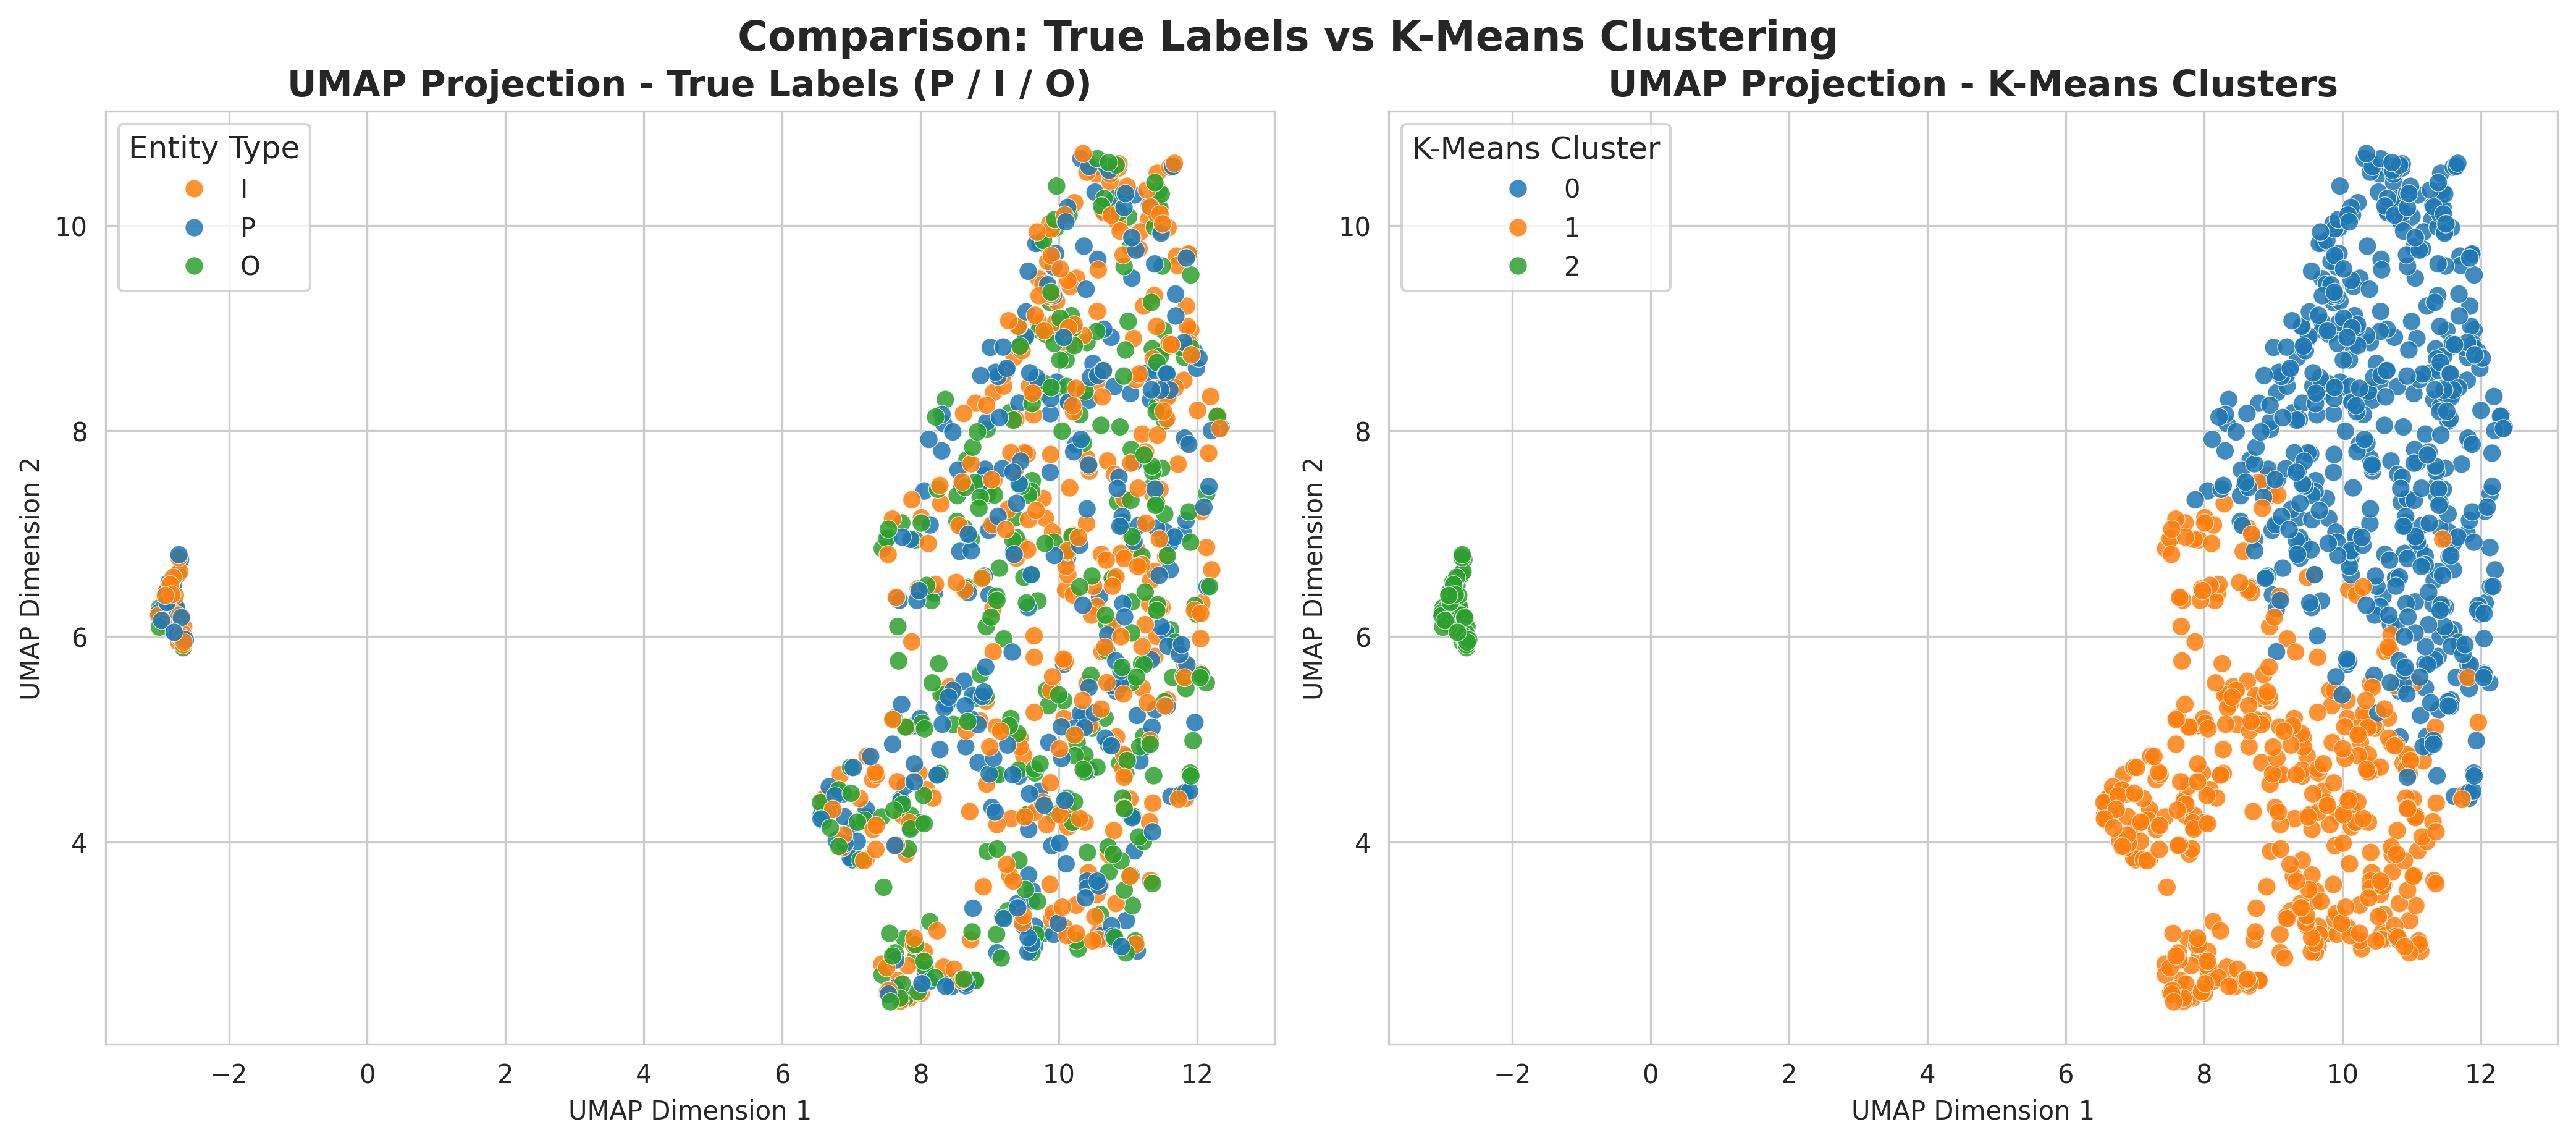

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300

plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
sns.scatterplot(data=df_umap, x='UMAP1', y='UMAP2', hue='True_Label',
                palette={'P': '#1f77b4', 'I': '#ff7f0e', 'O': '#2ca02c'},
                s=50, alpha=0.85, edgecolor='white', linewidth=0.3)
plt.title('UMAP Projection - True Labels (P / I / O)', fontsize=14, fontweight='bold')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='Entity Type', title_fontsize=12)

# K-Means Clusters
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_umap, x='UMAP1', y='UMAP2', hue='KMeans_Cluster',
                palette='tab10', s=50, alpha=0.85, edgecolor='white', linewidth=0.3)
plt.title('UMAP Projection - K-Means Clusters', fontsize=14, fontweight='bold')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='K-Means Cluster', title_fontsize=12)

plt.tight_layout()
plt.suptitle('Comparison: True Labels vs K-Means Clustering',
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

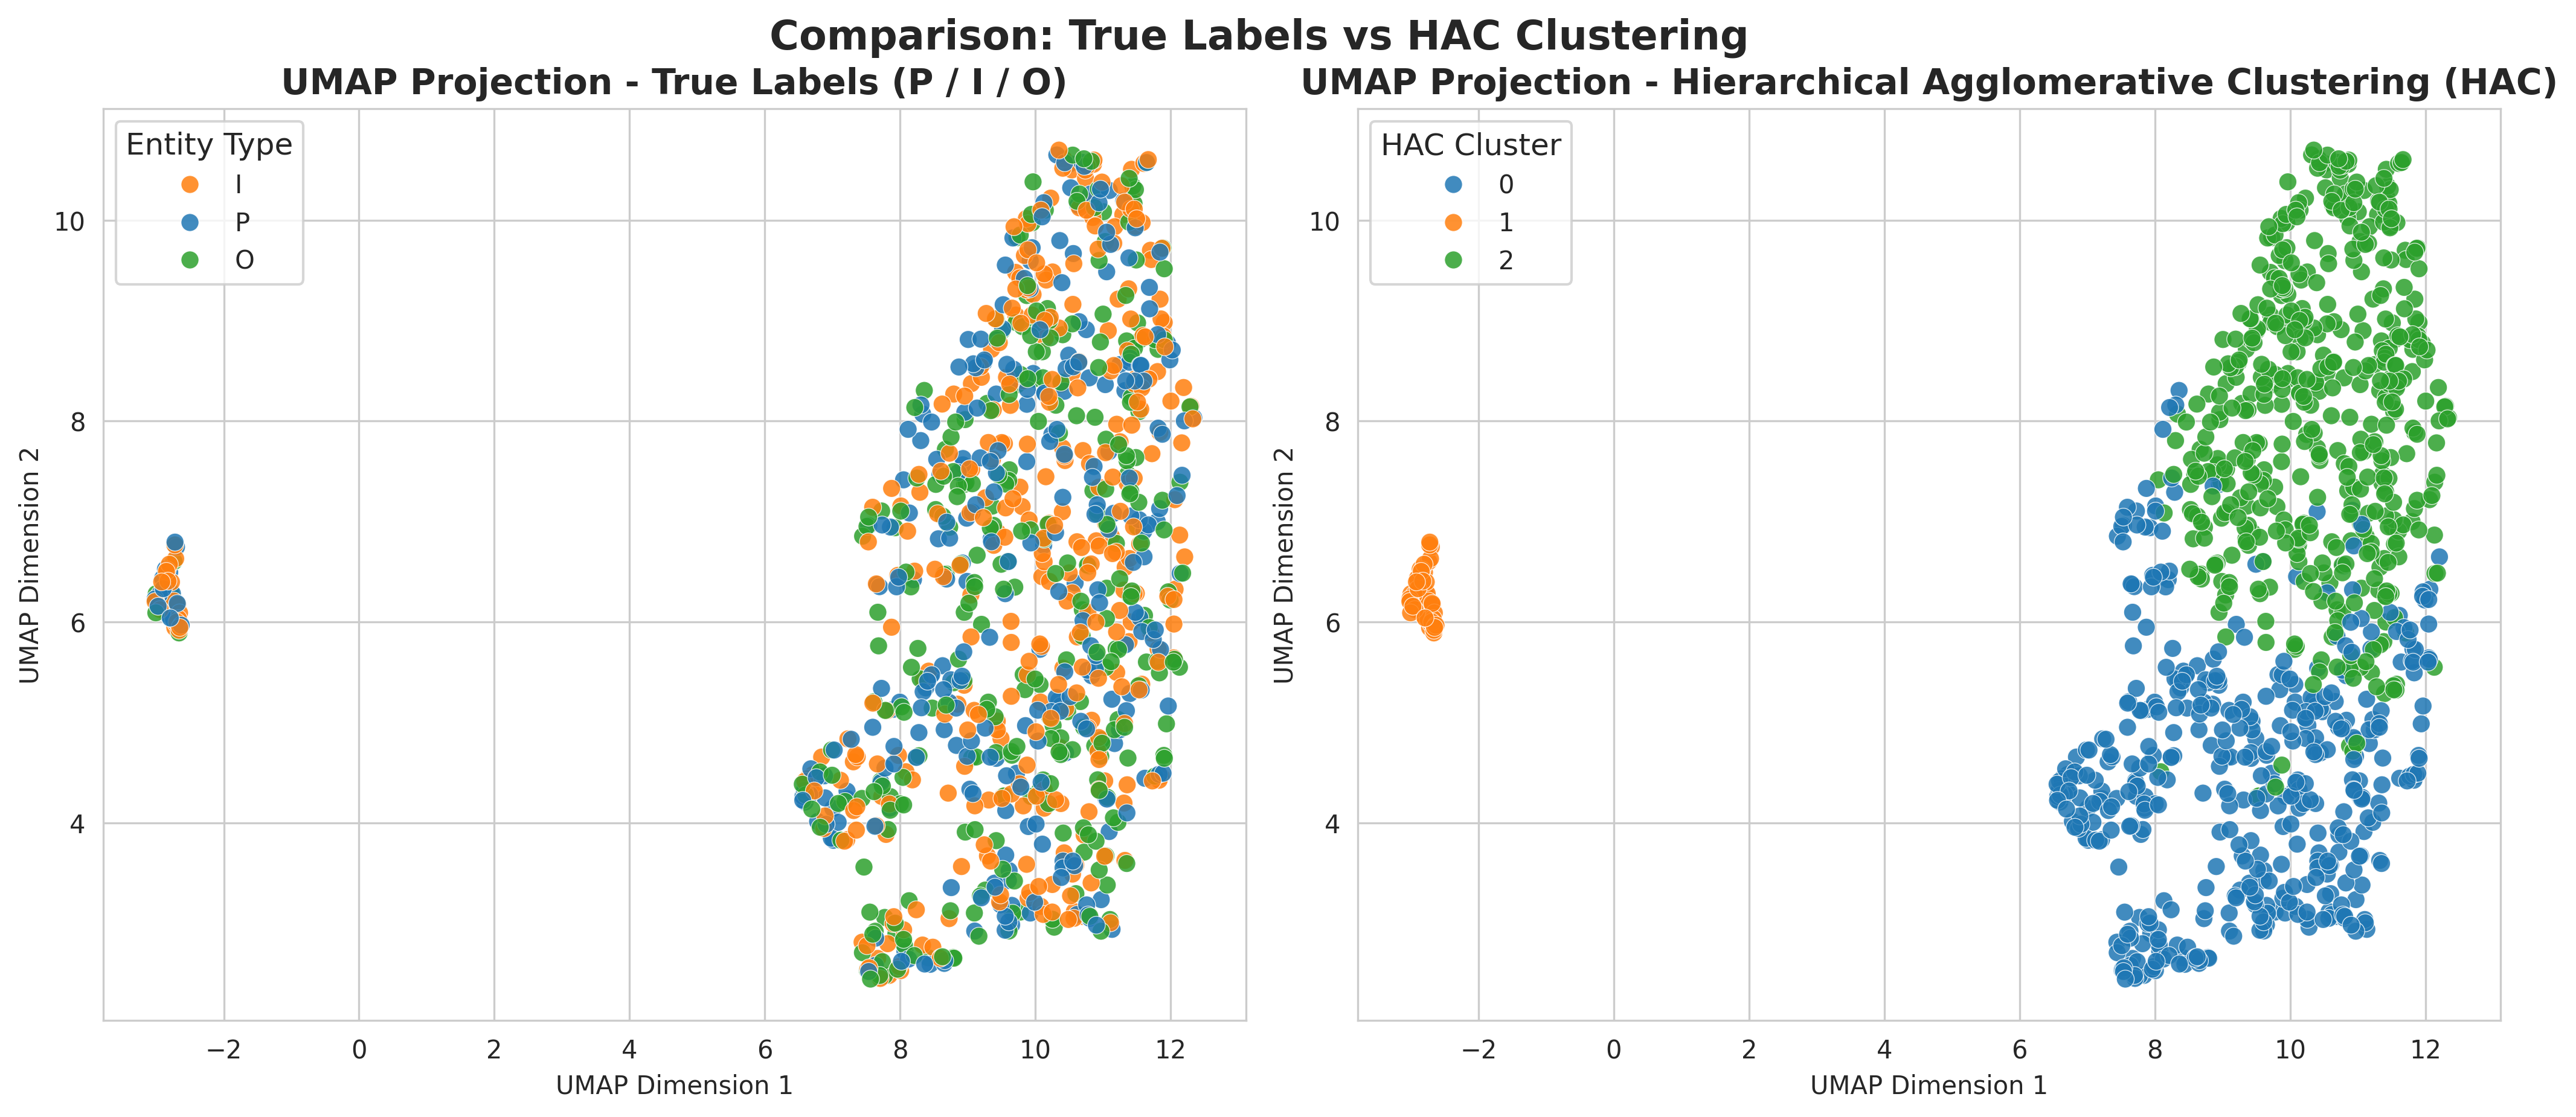

In [143]:

plt.figure(figsize=(14, 6))

# True Labels
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_umap, x='UMAP1', y='UMAP2', hue='True_Label',
                palette={'P': '#1f77b4', 'I': '#ff7f0e', 'O': '#2ca02c'},
                s=50, alpha=0.85, edgecolor='white', linewidth=0.3)
plt.title('UMAP Projection - True Labels (P / I / O)', fontsize=14, fontweight='bold')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='Entity Type', title_fontsize=12)

# HAC Clusters
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_umap, x='UMAP1', y='UMAP2', hue='HAC_Cluster',
                palette='tab10', s=50, alpha=0.85, edgecolor='white', linewidth=0.3)
plt.title('UMAP Projection - Hierarchical Agglomerative Clustering (HAC)',
          fontsize=14, fontweight='bold')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='HAC Cluster', title_fontsize=12)

plt.tight_layout()
plt.suptitle('Comparison: True Labels vs HAC Clustering',
             fontsize=16, fontweight='bold', y=1.02)
plt.show()